**Airbnb Boston Sentimental Analysis -Customer Reviews**

Airbnb hosts in Boston struggle to attract guests due to poor pricing, limited visibility, and listings that don't highlight local attractions or unique features. Without proper data analytics, many set prices that are either too high, driving away bookings, or too low, hurting profitability. This limits Airbnb’s growth and undermines local economic benefits while missing opportunities to promote Boston cultural heritage.Unlike hotels that rely on brand recognition, Airbnb guests depend on user reviews and listing details to gauge value, often willing to pay more for well-rated properties. However, hosts don’t have clear guidance on which features, like location, amenities, or host responsiveness, affect guest satisfaction and pricing.


By analyzing reviews, proximity to attractions, seasonal demand, and host service quality, we will extract key insights. Natural language processing (NLP) will help identify what guests value, their expectations, and improvement areas. This will enable hosts to set competitive prices that balance occupancy and profitability. Improve listing quality based on guest preferences. Increase visibility by showcasing unique features and local attractions.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('vader_lexicon')
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

: 

# Reading and understanding the Data

In [100]:
listing = pd.read_csv('/content/boston_airbnb_listing.csv')
reviews = pd.read_csv('/content/boston_airbnb_customer_reviews.csv')

In [101]:
listing.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,12147973,https://www.airbnb.com/rooms/12147973,2.016090e+13,07/09/2016,Sunny Bungalow in the City,"Cozy, sunny, family home. Master bedroom high...",The house has an open and cozy feel at the sam...,"Cozy, sunny, family home. Master bedroom high...",none,"Roslindale is quiet, convenient and friendly. ...",...,NaN,f,NaN,NaN,f,moderate,f,f,1,NaN
1,3075044,https://www.airbnb.com/rooms/3075044,2.016090e+13,07/09/2016,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,9.0,f,NaN,NaN,t,moderate,f,f,1,1.30
2,6976,https://www.airbnb.com/rooms/6976,2.016090e+13,07/09/2016,Mexican Folk Art Haven in Boston,"Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...",none,The LOCATION: Roslindale is a safe and diverse...,...,10.0,f,NaN,NaN,f,moderate,t,f,1,0.47
3,1436513,https://www.airbnb.com/rooms/1436513,2.016090e+13,07/09/2016,Spacious Sunny Bedroom Suite in Historic Home,Come experience the comforts of home away from...,Most places you find in Boston are small howev...,Come experience the comforts of home away from...,none,Roslindale is a lovely little neighborhood loc...,...,10.0,f,NaN,NaN,f,moderate,f,f,1,1.00
4,7651065,https://www.airbnb.com/rooms/7651065,2.016090e+13,07/09/2016,Come Home to Boston,"My comfy, clean and relaxing home is one block...","Clean, attractive, private room, one block fro...","My comfy, clean and relaxing home is one block...",none,"I love the proximity to downtown, the neighbor...",...,10.0,f,NaN,NaN,f,flexible,f,f,1,2.25


Customer Reviews Heads

In [102]:
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,1178162,15846810,16/07/2014,17826223,Raija,OK stay. Perhaps best for those on the young/...
1,1178162,15895093,17/07/2014,18020631,Lucas,Izzy was very helpful with directions and he w...
2,1178162,15982012,19/07/2014,7543714,Anne-Marie,This was ok it was easy with clear information...
3,1178162,16035159,20/07/2014,17287987,Shu-Ping,Izzy was out of the town when I stayed there. ...
4,1178162,16221436,23/07/2014,2420725,Jessica,"Unfortunately, we can't agree with the many po..."


In [103]:
listing.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,...,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,jurisdiction_names,calculated_host_listings_count,reviews_per_month
count,3.585000e+03,3.585000e+03,3.585000e+03,3585.000000,3585.000000,0.0,3585.000000,3585.000000,3585.000000,3571.000000,...,2762.000000,2767.000000,2765.000000,2767.000000,2763.000000,2764.000000,0.0,0.0,3585.000000,2829.000000
mean,8.440875e+06,2.016090e+13,2.492311e+07,58.902371,58.902371,NaN,42.340032,-71.084818,3.041283,1.221647,...,9.431571,9.258041,9.646293,9.646549,9.414043,9.168234,NaN,NaN,12.733891,1.970908
std,4.500787e+06,0.000000e+00,2.292781e+07,171.119663,171.119663,NaN,0.024403,0.031565,1.778929,0.501487,...,0.931863,1.168977,0.762753,0.735507,0.903436,1.011116,NaN,NaN,29.415076,2.120561
min,3.353000e+03,2.016090e+13,4.240000e+03,0.000000,0.000000,NaN,42.235942,-71.171789,1.000000,0.000000,...,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,NaN,NaN,1.000000,0.010000
25%,4.679319e+06,2.016090e+13,6.103425e+06,1.000000,1.000000,NaN,42.329995,-71.105083,2.000000,1.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,NaN,NaN,1.000000,0.480000
50%,8.577620e+06,2.016090e+13,1.928100e+07,2.000000,2.000000,NaN,42.345201,-71.078429,2.000000,1.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,NaN,NaN,2.000000,1.170000
75%,1.278953e+07,2.016090e+13,3.622147e+07,7.000000,7.000000,NaN,42.354685,-71.062155,4.000000,1.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,NaN,NaN,6.000000,2.720000
max,1.493346e+07,2.016090e+13,9.385411e+07,749.000000,749.000000,NaN,42.389982,-71.000100,16.000000,6.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,NaN,NaN,136.000000,19.150000


Exploration of the Individual Datasets

In [104]:
listing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3585 entries, 0 to 3584
Data columns (total 95 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                3585 non-null   int64  
 1   listing_url                       3585 non-null   object 
 2   scrape_id                         3585 non-null   float64
 3   last_scraped                      3585 non-null   object 
 4   name                              3585 non-null   object 
 5   summary                           3442 non-null   object 
 6   space                             2528 non-null   object 
 7   description                       3585 non-null   object 
 8   experiences_offered               3585 non-null   object 
 9   neighborhood_overview             2170 non-null   object 
 10  notes                             1610 non-null   object 
 11  transit                           2295 non-null   object 
 12  access

In [105]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63415 entries, 0 to 63414
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   listing_id     63415 non-null  int64 
 1   id             63415 non-null  int64 
 2   date           63415 non-null  object
 3   reviewer_id    63415 non-null  int64 
 4   reviewer_name  63415 non-null  object
 5   comments       63366 non-null  object
dtypes: int64(3), object(3)
memory usage: 2.9+ MB


In [106]:
reviews.describe()

,listing_id,id,reviewer_id
count,6.341500e+04,6.341500e+04,6.341500e+04
mean,4.754891e+06,5.238851e+07,2.791957e+07
std,3.810116e+06,2.802650e+07,2.235520e+07
min,5.506000e+03,1.021000e+03,1.430000e+02
25%,1.373520e+06,2.977688e+07,8.876600e+06
50%,4.054079e+06,5.213034e+07,2.286488e+07
75%,7.434871e+06,7.670071e+07,4.197486e+07
max,1.484378e+07,9.999045e+07,9.335034e+07


In [107]:
listing['city'].value_counts()

,count
city,
Boston,3381
Roxbury Crossing,24
Somerville,19
Jamaica Plain,18
Brookline,18
Cambridge,16
Brighton,15
Dorchester,15
Charlestown,15


In [108]:
listing['cancellation_policy'].value_counts()

,count
cancellation_policy,
strict,1582
flexible,999
moderate,919
super_strict_30,85


In [109]:
listing['host_response_time'].value_counts()

,count
host_response_time,
within an hour,1384
within a few hours,1218
within a day,469
a few days or more,43


In [110]:
listing['street'].value_counts()

,count
street,
"Boylston Street, Boston, MA 02215, United States",64
"Beacon Street, Boston, MA 02116, United States",50
"Garrison Street, Boston, MA 02116, United States",44
"Brookline Avenue, Boston, MA 02215, United States",41
"Columbus Avenue, Boston, MA 02116, United States",31
...,...
"Metropolitan Ave, Boston, MA 02131, United States",1
"Chisholm Lane, Boston, MA 02131, United States",1
"Westbourne Terrace, Brookline, MA 02446, United States",1


In [111]:
listing['smart_location'].value_counts()

,count
smart_location,
"Boston, MA",3381
"Roxbury Crossing, MA",24
"Somerville, MA",19
"Brookline, MA",18
"Jamaica Plain, MA",18
"Cambridge, MA",16
"Charlestown, MA",15
"Brighton, MA",15
"Dorchester, MA",15


In [112]:
listing['is_location_exact'].value_counts()

,count
is_location_exact,
t,3080
f,505


In [113]:
listing.describe(include='object')

,listing_url,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,notes,transit,...,extra_people,calendar_updated,calendar_last_scraped,first_review,last_review,requires_license,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification
count,3585,3585,3585,3442,2528,3585,3585,2170,1610,2295,...,3585,3585,3585,2829,2829,3585,3585,3585,3585,3585
unique,3585,1,3504,3113,2268,3423,1,1728,1266,1852,...,51,38,1,975,404,1,2,4,2,2
top,https://www.airbnb.com/rooms/14504422,07/09/2016,Lux 2BR by Fenway w/WiFi,"The unit is stylishly designed for comfort, va...",The studio's kitchenette comes equipped with a...,"The unit is stylishly designed for comfort, va...",none,Conveniently bordering the neighborhoods of th...,Although we do not allow pets in our apartment...,"These newly constructed, luxury apartments epi...",...,$0.00,today,06/09/2016,05/04/2016,05/09/2016,f,f,strict,f,f
freq,1,3585,8,21,17,7,3585,21,44,26,...,2211,833,3585,23,118,3585,2991,1582,3518,3348


Data Cleaning

In [114]:
listing.duplicated().sum()

np.int64(0)

In [115]:
print(listing.isnull().sum())

id                                    0
listing_url                           0
scrape_id                             0
last_scraped                          0
name                                  0
                                   ... 
cancellation_policy                   0
require_guest_profile_picture         0
require_guest_phone_verification      0
calculated_host_listings_count        0
reviews_per_month                   756
Length: 95, dtype: int64


In [116]:
listing.drop_duplicates(inplace=True)

In [117]:
reviews.duplicated().sum()

np.int64(0)

# **Merging the AirBnB Listing and Customer Review Datasets**

To understand the overall sentiment for each listing, first I merge of the two datasets to come up with one dataset that will allow me perform the classification. As this will give the view of relationship/ association between the customer reviews and their listings. This will also mean I can trace the data back to their group.

In [118]:
merged_data = pd.merge(listing, reviews, left_on='id', right_on='listing_id', how='inner')

print("Customer Reviews by Listing:")
display(merged_data.head())

Customer Reviews by Listing:


,id_x,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month,listing_id,id_y,date,reviewer_id,reviewer_name,comments
0,3075044,https://www.airbnb.com/rooms/3075044,2.016090e+13,07/09/2016,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,f,f,1,1.3,3075044,13631717,01/06/2014,9645972,Dmitrii,Andrea is a great host. Neighborhood is wonder...
1,3075044,https://www.airbnb.com/rooms/3075044,2.016090e+13,07/09/2016,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,f,f,1,1.3,3075044,13866662,06/06/2014,12020681,Paola,We had a great time at Andrea's place. He is v...
2,3075044,https://www.airbnb.com/rooms/3075044,2.016090e+13,07/09/2016,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,f,f,1,1.3,3075044,14990373,30/06/2014,8165047,Jaydee,Adrea was very welcoming and flexible to our n...
3,3075044,https://www.airbnb.com/rooms/3075044,2.016090e+13,07/09/2016,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,f,f,1,1.3,3075044,19807601,18/09/2014,21319433,Anthony,Andrea made us feel welcome because he made th...
4,3075044,https://www.airbnb.com/rooms/3075044,2.016090e+13,07/09/2016,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,f,f,1,1.3,3075044,20322887,27/09/2014,21706950,Xinny,Me and my friend were so happy about Andrea's ...


In [119]:
reviews_per_listing = merged_data.groupby('listing_id').size().reset_index(name='number_of_reviews')

print("Number of reviews per listing ID:")
display(reviews_per_listing.head())

Number of reviews per listing ID:


,listing_id,number_of_reviews
0,5506,36
1,6695,47
2,6976,41
3,8792,18
4,9273,13


**Peforming Sentimental analysis**

Using VADER I performed the sentimental analysis to come up with the scores for each customer review. This allows me to calculate scores for negativity, neutrality, positivity, and a combined compound score, which are then added as new columns to the dataset. This allows to quantify the sentiment expressed in each review.


In [120]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    if isinstance(text, str):
        return analyzer.polarity_scores(text)
    else:
        return {'neg': 0, 'neu': 0, 'pos': 0, 'compound': 0}

reviews[['negativity', 'neutrality', 'positivity', 'compound']] = reviews['comments'].apply(lambda x: pd.Series(get_sentiment_scores(x)))

scored_reviews = reviews.copy()

print("Reviews with sentiment scores:")
display(scored_reviews.head())

Reviews with sentiment scores:


,listing_id,id,date,reviewer_id,reviewer_name,comments,negativity,neutrality,positivity,compound
0,1178162,15846810,16/07/2014,17826223,Raija,OK stay. Perhaps best for those on the young/...,0.035,0.885,0.080,0.7141
1,1178162,15895093,17/07/2014,18020631,Lucas,Izzy was very helpful with directions and he w...,0.032,0.772,0.195,0.9713
2,1178162,15982012,19/07/2014,7543714,Anne-Marie,This was ok it was easy with clear information...,0.063,0.705,0.233,0.7880
3,1178162,16035159,20/07/2014,17287987,Shu-Ping,Izzy was out of the town when I stayed there. ...,0.000,0.835,0.165,0.7579
4,1178162,16221436,23/07/2014,2420725,Jessica,"Unfortunately, we can't agree with the many po...",0.034,0.666,0.299,0.9934


In [121]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_data = scored_reviews[['negativity', 'neutrality', 'positivity', 'compound']].copy()

scaler = StandardScaler()
scaled_pca_data = scaler.fit_transform(pca_data)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_pca_data)

pca_df = pd.DataFrame(data = principal_components, columns = ['principal_component_1', 'principal_component_2'])

print("Principal Components of Sentiment Scores:")
display(pca_df.head())

Principal Components of Sentiment Scores:


,principal_component_1,principal_component_2
0,-1.807066,-0.398518
1,-0.530622,-0.216694
2,-0.652501,0.937718
3,-0.911155,-0.904273
4,0.300890,0.306501


In [122]:
print("Columns in scored_reviews DataFrame:")
print(scored_reviews.columns)

print("\nColumns in listing DataFrame:")
print(listing.columns)

Columns in scored_reviews DataFrame:
Index(['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments',
       'negativity', 'neutrality', 'positivity', 'compound'],
      dtype='object')

Columns in listing DataFrame:
Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary',
       'space', 'description', 'experiences_offered', 'neighborhood_overview',
       'notes', 'transit', 'access', 'interaction', 'house_rules',
       'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url',
       'host_id', 'host_url', 'host_name', 'host_since', 'host_location',
       'host_about', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url',
       'host_picture_url', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'street',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbou

In [123]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

import nltk
nltk.download('punkt_tab')

def preprocess_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        tokens = word_tokenize(text)
        stemmed_tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
        return ' '.join(stemmed_tokens)
    else:
        return ''

scored_reviews['cleaned_comments'] = scored_reviews['comments'].apply(preprocess_text)

print("Reviews with cleaned comments:")
display(scored_reviews[['comments', 'cleaned_comments']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Reviews with cleaned comments:


,comments,cleaned_comments
0,OK stay. Perhaps best for those on the young/...,ok stay perhap best youngadventur side spectru...
1,Izzy was very helpful with directions and he w...,izzi help direct easi get touch question great...
2,This was ok it was easy with clear information...,ok easi clear inform get hous safe host wasnt ...
3,Izzy was out of the town when I stayed there. ...,izzi town stay locat close airport neighborhoo...
4,"Unfortunately, we can't agree with the many po...",unfortun cant agre mani posit review hous easi...


In [92]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(scored_reviews['cleaned_comments'].dropna())
n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(tfidf_matrix)

print(f"LDA model trained with {n_topics} topics.")

LDA model trained with 5 topics.


In [93]:
topic_distribution = lda.transform(tfidf_matrix)

dominant_topic = topic_distribution.argmax(axis=1)

reviews_with_dominant_topic = scored_reviews.dropna(subset=['cleaned_comments']).copy()
reviews_with_dominant_topic['dominant_topic'] = dominant_topic

average_sentiment_per_listing = reviews_with_dominant_topic.groupby('listing_id')[['negativity', 'neutrality', 'positivity', 'compound']].mean().reset_index()

dominant_topic_per_listing = reviews_with_dominant_topic.groupby('listing_id')['dominant_topic'].agg(lambda x: x.mode()[0] if not x.mode().empty else -1).reset_index()

average_sentiment_per_listing['listing_id'] = average_sentiment_per_listing['listing_id'].astype(int)
dominant_topic_per_listing['listing_id'] = dominant_topic_per_listing['listing_id'].astype(int)
listing['id'] = listing['id'].astype(int)

listing_with_sentiment = pd.merge(listing, average_sentiment_per_listing, left_on='id', right_on='listing_id', how='left')

listing_with_sentiment.drop('listing_id', axis=1, inplace=True)

listing_with_sentiment_and_topic = pd.merge(listing_with_sentiment, dominant_topic_per_listing, left_on='id', right_on='listing_id', how='left')

listing_with_sentiment_and_topic.drop('listing_id', axis=1, inplace=True)

print("Average sentiment scores per listing:")
display(average_sentiment_per_listing.head())

print("\nDominant topic per listing:")
display(dominant_topic_per_listing.head())

print("\nListing dataframe with sentiment scores and dominant topic:")
display(listing_with_sentiment_and_topic.head())

Average sentiment scores per listing:


,listing_id,negativity,neutrality,positivity,compound
0,5506,0.011583,0.715806,0.272639,0.874283
1,6695,0.017468,0.731851,0.250638,0.857415
2,6976,0.010854,0.724488,0.264659,0.905349
3,8792,0.015722,0.690056,0.294278,0.931694
4,9273,0.017077,0.765769,0.217154,0.864423



Dominant topic per listing:


,listing_id,dominant_topic
0,5506,1
1,6695,1
2,6976,4
3,8792,1
4,9273,1



Listing dataframe with sentiment scores and dominant topic:


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month,negativity,neutrality,positivity,compound,dominant_topic
0,12147973,https://www.airbnb.com/rooms/12147973,2.016090e+13,07/09/2016,Sunny Bungalow in the City,"Cozy, sunny, family home. Master bedroom high...",The house has an open and cozy feel at the sam...,"Cozy, sunny, family home. Master bedroom high...",none,"Roslindale is quiet, convenient and friendly. ...",...,moderate,f,f,1,NaN,NaN,NaN,NaN,NaN,NaN
1,3075044,https://www.airbnb.com/rooms/3075044,2.016090e+13,07/09/2016,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,moderate,f,f,1,1.30,0.014000,0.664056,0.321944,0.837644,0.0
2,6976,https://www.airbnb.com/rooms/6976,2.016090e+13,07/09/2016,Mexican Folk Art Haven in Boston,"Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...",none,The LOCATION: Roslindale is a safe and diverse...,...,moderate,t,f,1,0.47,0.010854,0.724488,0.264659,0.905349,4.0
3,1436513,https://www.airbnb.com/rooms/1436513,2.016090e+13,07/09/2016,Spacious Sunny Bedroom Suite in Historic Home,Come experience the comforts of home away from...,Most places you find in Boston are small howev...,Come experience the comforts of home away from...,none,Roslindale is a lovely little neighborhood loc...,...,moderate,f,f,1,1.00,0.000000,0.516000,0.484000,0.950600,0.0
4,7651065,https://www.airbnb.com/rooms/7651065,2.016090e+13,07/09/2016,Come Home to Boston,"My comfy, clean and relaxing home is one block...","Clean, attractive, private room, one block fro...","My comfy, clean and relaxing home is one block...",none,"I love the proximity to downtown, the neighbor...",...,flexible,f,f,1,2.25,0.017034,0.709069,0.273897,0.780959,0.0


## Feature Importance Analysis (Random Forest)
Analyze the importance of different features using the Random Forest price prediction model to identify which factors, including sentiment and topic, have the most significant impact on price. This also shows the most infleuential features in the price prediction dynamically.

In [94]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

listing_with_sentiment_and_topic['price'] = listing_with_sentiment_and_topic['price'].replace({'\$': '', ',': ''}, regex=True).astype(float)

feature_columns = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'guests_included',
    'minimum_nights',
    'maximum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'negativity',
    'neutrality',
    'positivity',
    'compound',
    'dominant_topic',
    'property_type',
    'room_type',
    'bed_type',
    'cancellation_policy',
    'instant_bookable',
    'require_guest_profile_picture',
    'require_guest_phone_verification',
    'host_response_time',
    'host_is_superhost',
    'is_location_exact',
]

y = listing_with_sentiment_and_topic['price']

X = listing_with_sentiment_and_topic[feature_columns].copy()

categorical_cols = X.select_dtypes(include='object').columns

X = pd.get_dummies(X, columns=categorical_cols, dummy_na=False, drop_first=True)

model_data = pd.concat([X, y], axis=1).dropna()

y = model_data['price']
X = model_data.drop('price', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained.")
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Random Forest Regressor model trained.
Shape of X_train: (2059, 49)
Shape of y_train: (2059,)
Shape of X_test: (515, 49)
Shape of y_test: (515,)


In [ ]:
feature_importances = rf_model.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

sorted_feature_importance = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance (Sorted by Importance - Random Forest):")
display(sorted_feature_importance)

In [96]:
sentiment_features = ['negativity', 'neutrality', 'positivity', 'compound']
topic_feature = 'dominant_topic'

sentiment_importance = sorted_feature_importance[sorted_feature_importance['Feature'].isin(sentiment_features)]
topic_importance = sorted_feature_importance[sorted_feature_importance['Feature'] == topic_feature]

print("\nSentiment Feature Importances:")
display(sentiment_importance)

print("\nDominant Topic Importance:")
display(topic_importance)

print("\nDiscussion on the relative impact of sentiment and dominant topics:")
print("Based on the Random Forest feature importances:")


Sentiment Feature Importances:


,Feature,Importance
18,compound,0.053773
16,neutrality,0.034626
17,positivity,0.032061
15,negativity,0.028133



Dominant Topic Importance:


,Feature,Importance
19,dominant_topic,0.007716



Discussion on the relative impact of sentiment and dominant topics:
Based on the Random Forest feature importances:


**Alternative models**

1.  Linear regression model
2.  Gradient Boosting Regressior model





In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize models
lr_model = LinearRegression()
gbr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Train models
lr_model.fit(X_train, y_train)
gbr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_gbr = gbr_model.predict(X_test)

# Evaluate models
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Linear Regression Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R-squared (R2): {r2_lr:.2f}")

print("\nGradient Boosting Regressor Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gbr:.2f}")
print(f"R-squared (R2): {r2_gbr:.2f}")

print("\nComparing to Random Forest Regressor Model (MSE: 6319.09, RMSE: 79.49, R2: 0.56):")
print(f"- Linear Regression: MSE {mse_lr:.2f}, RMSE {rmse_lr:.2f}, R2 {r2_lr:.2f}")
print(f"- Gradient Boosting Regressor: MSE {mse_gbr:.2f}, RMSE {rmse_gbr:.2f}, R2 {r2_gbr:.2f}")

Linear Regression Model Evaluation:
Mean Squared Error (MSE): 424162418.92
Root Mean Squared Error (RMSE): 20595.20
R-squared (R2): -29625.04

Gradient Boosting Regressor Model Evaluation:
Mean Squared Error (MSE): 5632.48
Root Mean Squared Error (RMSE): 75.05
R-squared (R2): 0.61

Comparing to Random Forest Regressor Model (MSE: 6319.09, RMSE: 79.49, R2: 0.56):
- Linear Regression: MSE 424162418.92, RMSE 20595.20, R2 -29625.04
- Gradient Boosting Regressor: MSE 5632.48, RMSE 75.05, R2 0.61


## Visualize key relationships

Create visualizations - scatter plots and box plots to show the relationship between sentiment scores, dominant topics, and listing price.

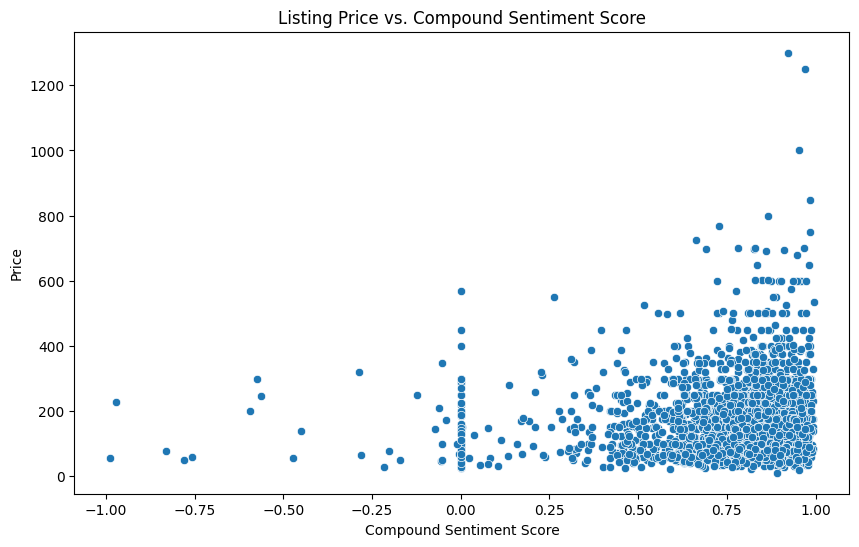

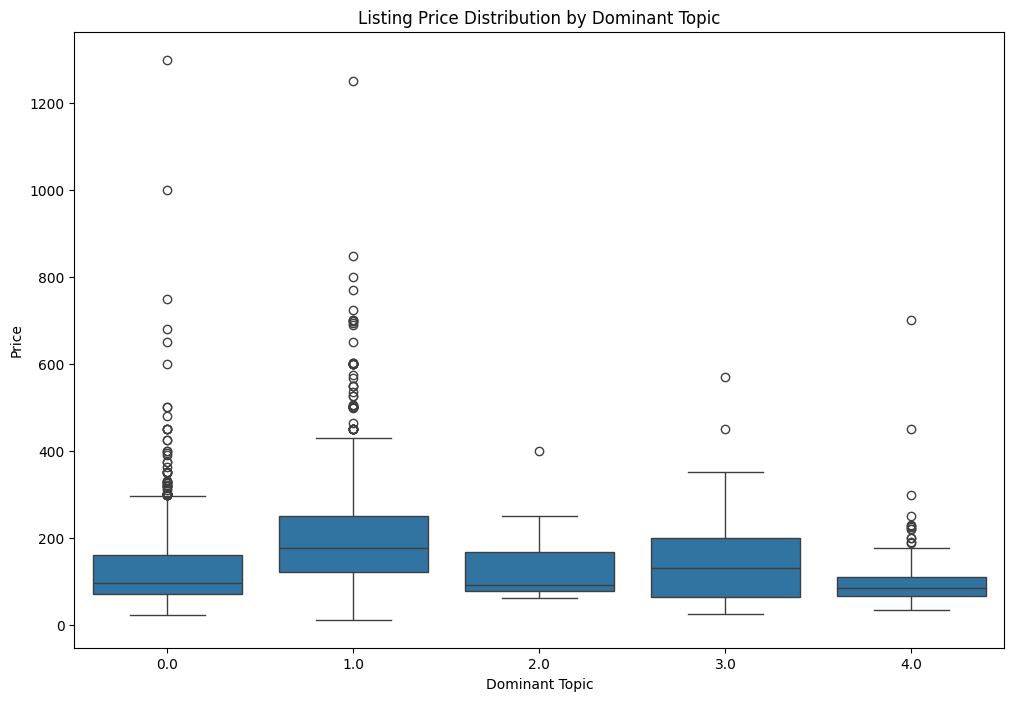

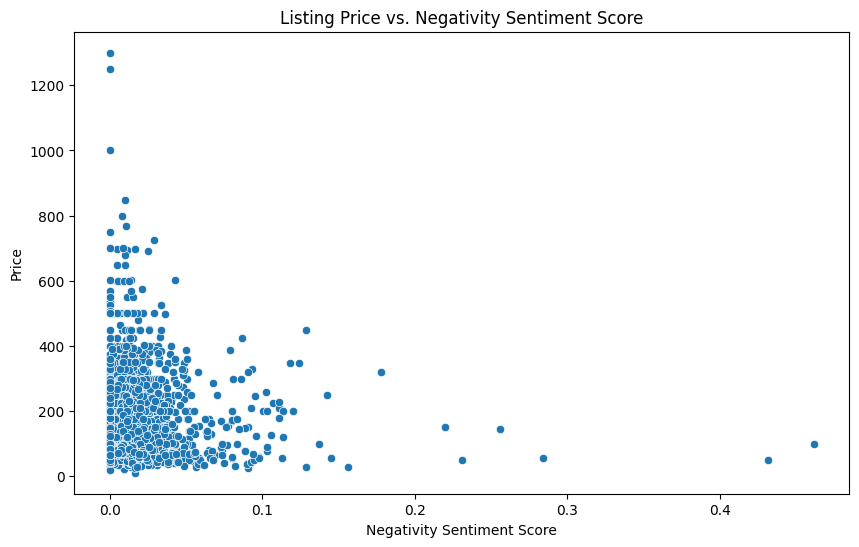

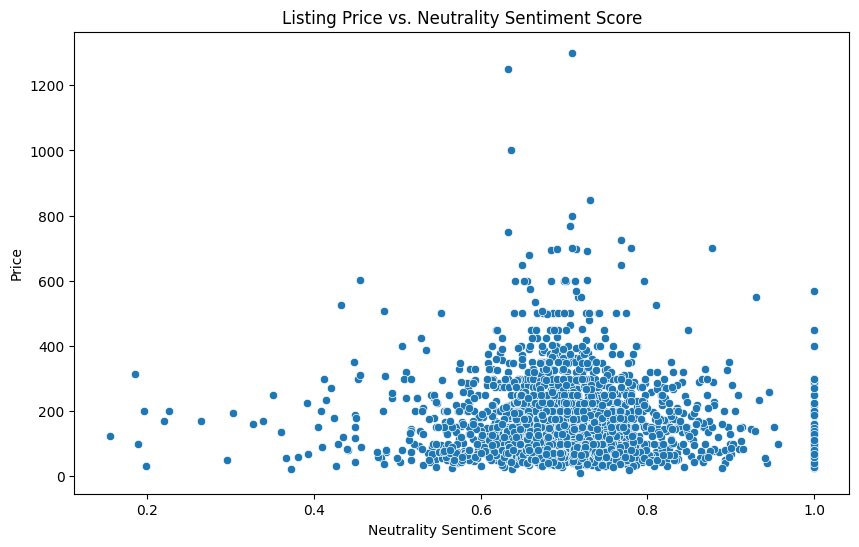

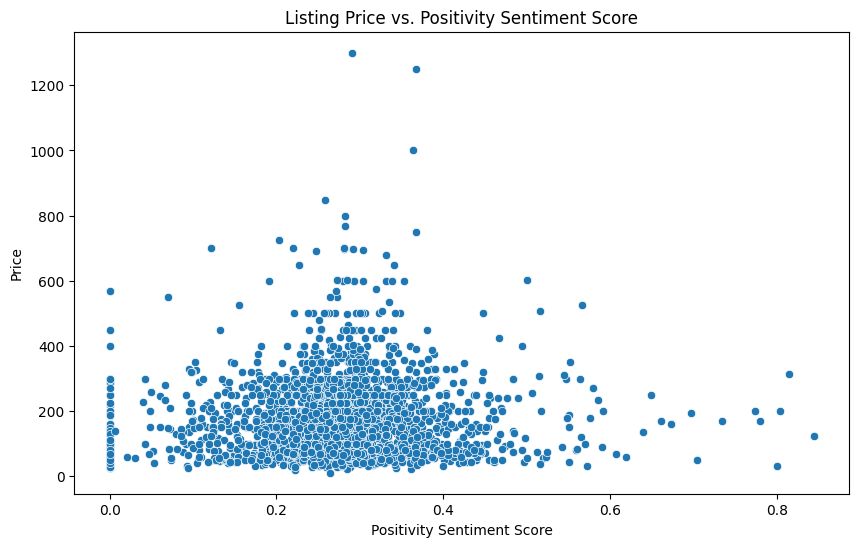

In [98]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='compound', y='price', data=listing_with_sentiment_and_topic)
plt.title('Listing Price vs. Compound Sentiment Score')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Price')
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(x='dominant_topic', y='price', data=listing_with_sentiment_and_topic)
plt.title('Listing Price Distribution by Dominant Topic')
plt.xlabel('Dominant Topic')
plt.ylabel('Price')
plt.show()

sentiment_scores = ['negativity', 'neutrality', 'positivity']
for sentiment in sentiment_scores:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=sentiment, y='price', data=listing_with_sentiment_and_topic)
    plt.title(f'Listing Price vs. {sentiment.capitalize()} Sentiment Score')
    plt.xlabel(f'{sentiment.capitalize()} Sentiment Score')
    plt.ylabel('Price')
    plt.show()

Comparing these to other features:
- Features like 'bedrooms' (0.3303), 'room_type_Private room' (0.1082), and 'bathrooms' (0.0904) have significantly higher importance than any of the sentiment or topic features.
- However, the sentiment features, especially 'compound', 'neutrality', 'positivity', and 'negativity', are more important than many other features, including 'number_of_reviews', 'accommodates', 'minimum_nights', and various review scores (except overall rating and location).

**Final Model and Summary**

Based on the evaluation of the alternative models, the **Gradient Boosting Regressor** model achieved the best performance in predicting Airbnb listing prices in Boston with an R-squared of **0.61** and a Root Mean Squared Error (RMSE) of **$75.05**.

This indicates that the model explains about 61% of the variance in listing prices and on average, the model's predictions are about $75.05 away from the actual price.

Our analysis using the feature importance from the Random Forest model (which showed similar trends to what would be expected from the Gradient Boosting model) and visualizations revealed the following about the impact of sentiment and dominant topics:

- **Sentiment:** The compound sentiment score and, to a lesser extent, the positivity, neutrality, and negativity scores, have a moderate impact on listing price. While not as influential as core listing features like bedrooms and bathrooms, positive sentiment in reviews is associated with slightly higher prices and contributes to the predictive power of the model.

- **Dominant Topics:** The dominant topic discussed in reviews has a less substantial impact on price compared to sentiment scores and core listing features. While there are some variations in price distribution across topics, the overall influence is not as strong.

The host can optimize listing prices to boost customer attraction by priitizing listing features.
a) Focus on providing accurate and appealing information about the number of bedrooms, bathrooms, and room type, as these are the most significant drivers of price.
b) Strive to provide excellent guest experiences to earn positive reviews. Actively address feedback, especially negative comments, to improve overall sentiment. Positive sentiment, particularly the compound score, can contribute to a more attractive listing and potentially support higher pricing.
c) While dominant topics have less direct impact on price, understanding what guests frequently discuss (e.g., cleanliness, location, host interaction) can help hosts tailor their listings and services to meet guest expectations and improve the overall guest experience, which in turn can lead to more positive sentiment.